In [121]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [122]:
#unclean dataset loading 
df=pd.read_csv("/Users/sanatwalia/Desktop/Assignments_applications/Player_Segmentation/dataset/messy_player_data.csv")

In [123]:
#Dataset inspection 
print("Printing the first 2 rows of the dataset \n")
print(df.head(2))

print("printing the unqique coount of each row in the dataset \n")  
print(df.nunique())

print("Printing the shape of the dataset \n")
print(df.shape)
print("Printing the columns of the dataset \n")
print(df.columns)



Printing the first 2 rows of the dataset 

  player_id signup_date country device_type avg_session_time  \
0     P0000  2025-02-21   India     Android            34.97   
1     P0001  2025-04-19   India          PC            28.62   

   sessions_per_week  last_purchase_amount         total_spent  level_reached  \
0                  4                 20.11               66.06             24   
1                  4                  3.63  40.830000000000005             89   

   retention_days  churned  satisfaction_score  bug_reports  has_premium  
0             131        0                 6.0          4.0         True  
1              49        0                10.0          NaN         True  
printing the unqique coount of each row in the dataset 

player_id               500
signup_date             173
country                   8
device_type               3
avg_session_time        468
sessions_per_week        14
last_purchase_amount    285
total_spent             492
level_reached 

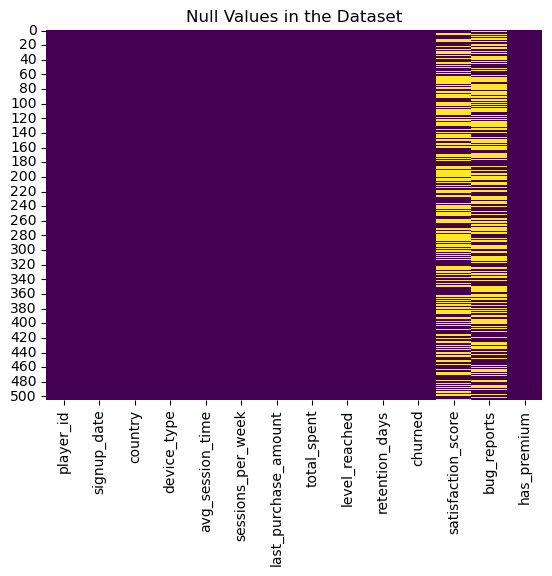

In [124]:
# Visaulising the null values in the datset using heatmap 
heatmap_df=pd.DataFrame(df.isnull())

sns.heatmap(heatmap_df, cbar=False, cmap='viridis')
plt.title("Null Values in the Dataset")
plt.show()

In [125]:
# By visalising we can see that there are null values in the dataset 
#counting the null values in the dataset
print("Printing the null values in the dataset \n") 
print(df.isnull().sum())
  


Printing the null values in the dataset 

player_id                 0
signup_date               0
country                   0
device_type               0
avg_session_time          0
sessions_per_week         0
last_purchase_amount      0
total_spent               0
level_reached             0
retention_days            0
churned                   0
satisfaction_score      251
bug_reports             258
has_premium               0
dtype: int64


In [126]:
# Satisfation score and bug_reports are the column with null values meaning users used to play the game but they did not give any feedback or report any bugs

# fixing the null values in the dataset
# Satisfaction score and bug reports have missing values
# Fill satisfaction with median
df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].median())

# Fill bug reports with 0 assuming no report was filed
df['bug_reports'] = df['bug_reports'].fillna(0)




In [127]:
# Finding the datatype of columns of the dataset 
print("Printing the data types of the dataset \n")
types = df.dtypes

print("Printing the data types of the dataset \n")
print(types)

 

Printing the data types of the dataset 

Printing the data types of the dataset 

player_id                object
signup_date              object
country                  object
device_type              object
avg_session_time         object
sessions_per_week         int64
last_purchase_amount    float64
total_spent              object
level_reached             int64
retention_days            int64
churned                   int64
satisfaction_score      float64
bug_reports             float64
has_premium                bool
dtype: object


In [128]:
# List of columns with object data type
object_columns = types[types == 'object'].index.tolist()

print("Printing the object columns of the dataset \n")
print(object_columns) 

Printing the object columns of the dataset 

['player_id', 'signup_date', 'country', 'device_type', 'avg_session_time', 'total_spent']


In [129]:
for col in object_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(5))



--- player_id ---
player_id
P0000    2
P0002    2
P0003    2
P0004    2
P0001    2
Name: count, dtype: int64

--- signup_date ---
signup_date
2024-12-30    8
2025-04-22    8
2025-04-19    8
2025-03-19    7
2024-12-18    7
Name: count, dtype: int64

--- country ---
country
UK         69
Germany    69
Japan      67
USA        64
Usa        63
Name: count, dtype: int64

--- device_type ---
device_type
PC         177
iOS        167
Android    161
Name: count, dtype: int64

--- avg_session_time ---
avg_session_time
31.04    3
31.42    3
29.65    3
20.48    2
37.68    2
Name: count, dtype: int64

--- total_spent ---
total_spent
66.06                 2
15.21                 2
1.57                  2
40.830000000000005    2
35.75                 2
Name: count, dtype: int64


In [130]:
# Converting object time columns to datetime 
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')

# Creating  new useful columns
df['signup_month'] = df['signup_date'].dt.month
df['signup_dayofweek'] = df['signup_date'].dt.dayofweek

# Dropping  original as  no longer needed
df.drop(columns=['signup_date'], inplace=True)


In [131]:
df['country'].unique()

array(['India', 'USA', 'Brazil', 'Inda', 'Usa', 'UK', 'Japan', 'Germany'],
      dtype=object)

In [132]:
# We have typos in the country column hence we need to fix them 
# Fix typos (like "Inda" to "India", "Usa" to "USA")
df['country'] = df['country'].replace({
    'Inda': 'India',
    'Usa': 'USA',
    'UK': 'United Kingdom'
})

# One-hot encode
df = pd.get_dummies(df, columns=['country'], prefix='country',dtype=int)


In [133]:
df['device_type'].unique()

array(['Android', 'PC', 'iOS'], dtype=object)

In [134]:
# No problems in the device type column
# One-hot encode    
df = pd.get_dummies(df, columns=['device_type'], prefix='device',dtype=int)

In [135]:
print("Printing the total values in the avg session time column ",df['avg_session_time'].value_counts().sum())
print("The total unique values in avg session time ",df['avg_session_time'].nunique())

Printing the total values in the avg session time column  505
The total unique values in avg session time  468


In [136]:
# Converting object columns to categorical
# Use previously defined fix function
def fix_avg_session_time(val):
    try:
        return float(val)
    except:
        return np.nan

df['avg_session_time'] = df['avg_session_time'].apply(fix_avg_session_time)


In [137]:
# Check the number of null values after conversion
print("The number of null values after conversion in avg_session_time",df['avg_session_time'].isnull().sum())

The number of null values after conversion in avg_session_time 1


In [138]:
# converting the null values in the avg session time column to the mean of the column
df['avg_session_time'] = df['avg_session_time'].fillna(df['avg_session_time'].median())

In [139]:
print("The number of null values after conversion in avg_session_time",df['avg_session_time'].isnull().sum())

The number of null values after conversion in avg_session_time 0


In [140]:
#Converting the total spent column to numeric
df['total_spent'][:2]

0                 66.06
1    40.830000000000005
Name: total_spent, dtype: object

In [141]:
def fix_total_spent(val):
    try:
        return float(val)
    except:
        return np.nan
df['total_spent'] = df['total_spent'].apply(fix_total_spent)

In [142]:
# Check the number of null values after conversion
print("The number of null values after conversion in avg_session_time",df['total_spent'].isnull().sum())

The number of null values after conversion in avg_session_time 1


In [143]:
df['total_spent'] = df['total_spent'].fillna(df['total_spent'].median())
print("The number of null values after conversion in avg_session_time",df['total_spent'].isnull().sum())

The number of null values after conversion in avg_session_time 0


In [144]:
df.head()

,player_id,avg_session_time,sessions_per_week,last_purchase_amount,total_spent,level_reached,retention_days,churned,satisfaction_score,bug_reports,...,signup_dayofweek,country_Brazil,country_Germany,country_India,country_Japan,country_USA,country_United Kingdom,device_Android,device_PC,device_iOS
0,P0000,34.97,4,20.11,66.06,24,131,0,6.0,4.0,...,4.0,0,0,1,0,0,0,1,0,0
1,P0001,28.62,4,3.63,40.83,89,49,0,10.0,0.0,...,5.0,0,0,1,0,0,0,0,1,0
2,P0002,31.42,4,0.00,142.54,14,9,1,10.0,4.0,...,4.0,0,0,0,0,1,0,1,0,0
3,P0003,29.65,5,4.96,15.02,4,2,1,6.0,5.0,...,3.0,1,0,0,0,0,0,0,0,1
4,P0004,16.72,7,0.00,2.31,40,82,0,6.0,7.0,...,0.0,0,0,1,0,0,0,0,0,1


In [145]:
df.to_csv("/Users/sanatwalia/Desktop/Assignments_applications/Player_Segmentation/dataset/player_data.csv")